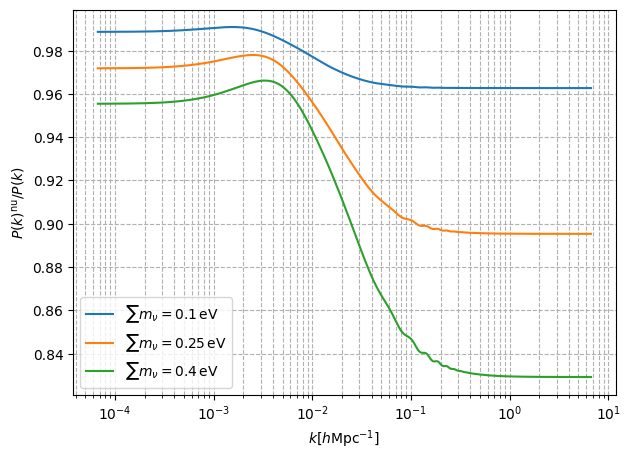

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from classy import Class
from scipy.optimize import fsolve

# --------------------------------------------------
# Paramètres communs
# --------------------------------------------------

common_settings = {
    'output': 'mPk',
    'P_k_max_h/Mpc': 50.0,
    'z_max_pk': 2.0,

    'h': 0.67,
    'omega_b': 0.02237,
    'omega_cdm': 0.1200,

    'A_s': 2.1e-9,
    'n_s': 0.965,
}

z = 0.0

k = np.logspace(-4, 1, 300)  # h/Mpc

pk_cb_massless = []
pk_cb_massive = []

plt.figure(figsize=(7,5))

# --------------------------------------------------
# neutrinos sans masse
# --------------------------------------------------

cosmo_massless = Class()

params_massless = common_settings.copy()
params_massless.update({
    'N_ur': 2.0328,
    'N_ncdm': 1,
    'm_ncdm': 1e-10
})

cosmo_massless.set(params_massless)
cosmo_massless.compute()

for ki in k:

    # CLASS attend k en 1/Mpc
    k_class = ki * common_settings['h']
    pk1 = cosmo_massless.pk_cb(k_class, z)
    pk_cb_massless.append(pk1)

pk_cb_massless = np.array(pk_cb_massless)

# --------------------------------------------------
# neutrinos massifs
# --------------------------------------------------
results_class = []


for sum_masses in [0.1, 0.25, 0.4]:

    cosmo_massive = Class()

    pk_cb_massive = []

    params_massive = common_settings.copy()
    params_massive.update({
        'N_ur': 2.0328,
        'N_ncdm': 1,
        'm_ncdm': sum_masses
    })

    cosmo_massive.set(params_massive)
    cosmo_massive.compute()

    for ki in k:

        k_class = ki * common_settings['h']

        pk2 = cosmo_massive.pk_cb(k_class, z)

        pk_cb_massive.append(pk2)

    pk_cb_massive = np.array(pk_cb_massive)

    ratio = pk_cb_massive / pk_cb_massless

    plt.semilogx(
        k*0.67,
        ratio,
        label=rf'$\sum m_\nu = {sum_masses}\,\mathrm{{eV}}$'
    )
    results_class.append({
        "k": k*0.67,
        "ratio": ratio,
        "mass": sum_masses,
        "method": "CLASS"
    })
    cosmo_massive.struct_cleanup()
    cosmo_massive.empty()

plt.xlabel(r'$k [h \mathrm{Mpc}^{-1}]$')
plt.ylabel(r'$P(k)^\mathrm{nu}/P(k)$')  
plt.grid(True, which='both', ls='--')
plt.legend(fontsize=10)

np.save("class_results.npy", results_class)
# --------------------------------------------------
# Nettoyage mémoire
# --------------------------------------------------

cosmo_massless.struct_cleanup()
cosmo_massless.empty()

cosmo_massive.struct_cleanup()
cosmo_massive.empty()

